# Proyecto Integrador · MNA**

---
## ▶ PASO 1 — conexión a Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
import subprocess, sys
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '--quiet',
    'ultralytics', 'opencv-python-headless', 'matplotlib', 'Pillow', 'scipy'
])
print('✅ Listo.')

Mounted at /content/drive
✅ Listo.


---
## ▶ PASO 2 — Carga de imagen

In [2]:
import os

# ══════════════════════════════════════════════════════════════════════════════════
DIR        = "/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/Data"
IMAGE_NAME = "new_image.jpg"
# ══════════════════════════════════════════════════════════════════════════════════

IMAGE_PATH    = os.path.join(DIR, IMAGE_NAME)
OUTPUT_DIR    = os.path.join(DIR, "resultados")
os.makedirs(OUTPUT_DIR, exist_ok=True)
stem          = os.path.splitext(IMAGE_NAME)[0]
OUTPUT_IMG    = os.path.join(OUTPUT_DIR, f"{stem}_v5_result.png")
OUTPUT_REPORT = os.path.join(OUTPUT_DIR, f"{stem}_v5_report.txt")

flag = '✅' if os.path.exists(IMAGE_PATH) else '❌ NO ENCONTRADA'
print(f'{flag}  {IMAGE_PATH}')

✅  /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/Data/new_image.jpg


---
## ▶ PASO 3 — Carga de librerías

In [3]:
import cv2, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings; warnings.filterwarnings('ignore')
from collections import defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from scipy import ndimage
from ultralytics import YOLO

PRODUCT_COLORS = {
    'bottle' : '#3B82F6',
    'can'    : '#EF4444',
    'box'    : '#F59E0B',
    'unknown': '#6B7280',
}
PRODUCT_LABELS_ES = {
    'bottle' : 'botellas',
    'can'    : 'latas',
    'box'    : 'cajas',
    'unknown': 'productos',
}
COCO_TO_PRODUCT = {
    'bottle':'bottle','wine glass':'bottle','cup':'can',
    'bowl':'unknown','book':'box','suitcase':'box','can':'can',
}
print('✅ Imports y constantes listas.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Imports y constantes listas.


---
## ▶ PASO 4 — Clases

In [4]:
@dataclass
class DetectedProduct:
    bbox        : Tuple[int,int,int,int]
    product_type: str
    confidence  : float
    source      : str   = 'grid'
    shelf_id    : int   = -1
    center_x    : float = 0.0
    center_y    : float = 0.0
    width_px    : float = 0.0
    height_px   : float = 0.0
    shape_score : float = 0.0

    def __post_init__(self):
        x1,y1,x2,y2   = self.bbox
        self.center_x  = (x1+x2)/2
        self.center_y  = (y1+y2)/2
        self.width_px  = float(x2-x1)
        self.height_px = float(y2-y1)


@dataclass
class ShelfLevel:
    shelf_id    : int
    y_top       : int
    y_bottom    : int
    products    : List[DetectedProduct] = field(default_factory=list)
    depth_factor: float = 1.0
    depth_conf  : str   = 'none'
    depth_note  : str   = ''

    @property
    def visible_count(self)   -> int: return len(self.products)
    @property
    def estimated_total(self) -> int: return max(round(self.visible_count * self.depth_factor), self.visible_count)
    @property
    def type_breakdown(self)  -> Dict[str,int]:
        c = defaultdict(int)
        for p in self.products: c[p.product_type] += 1
        return dict(c)
    @property
    def dominant_type(self) -> str:
        if not self.products: return 'unknown'
        bd = self.type_breakdown
        return max(bd, key=bd.get)

print('✅ Dataclasses listas.')

✅ Dataclasses listas.


---
## ▶ PASO 5 — ShapeClassifier

In [5]:
class ShapeClassifier:
    """
    Clasifica un recorte de imagen como 'can', 'bottle' o 'box'
    usando únicamente análisis geométrico del contorno y perfil de forma.
    No usa color → funciona en imágenes B&N, de baja luz, o cualquier paleta.
    """

    @staticmethod
    def classify(img_bgr: np.ndarray,
                 x1:int, y1:int, x2:int, y2:int
                 ) -> Tuple[str, float]:
        """
        Retorna (tipo, confianza)  donde tipo ∈ {'can','bottle','box','unknown'}
        y confianza ∈ [0,1].
        """
        patch = img_bgr[max(y1,0):max(y2,1), max(x1,0):max(x2,1)]
        if patch.size == 0:
            return 'unknown', 0.0

        ph, pw = patch.shape[:2]
        if ph < 10 or pw < 5:
            return 'unknown', 0.0

        ar = ph / max(pw, 1)

        # ── 1. Perfil de ancho vertical ───────────────────────
        # Para cada fila, medir el ancho del objeto (píxeles no negros)
        gray  = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY) if len(patch.shape)==3 else patch
        blur  = cv2.GaussianBlur(gray, (5,5), 0)
        _, bw = cv2.threshold(blur, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Perfil horizontal: suma de píxeles blancos por fila
        row_sums = bw.sum(axis=1) / 255.0   # ancho efectivo por fila
        if row_sums.max() == 0:
            return ShapeClassifier._fallback_ar(ar)

        row_norm = row_sums / row_sums.max()   # normalizado 0-1

        # ── 2. Detectar cuello (estrechamiento en tercio superior) ──
        n      = len(row_norm)
        top3   = row_norm[:n//3]    # tercio superior
        mid3   = row_norm[n//3: 2*n//3]
        bot3   = row_norm[2*n//3:]  # tercio inferior

        top_mean = top3.mean() if len(top3)>0 else 1.0
        mid_mean = mid3.mean() if len(mid3)>0 else 1.0
        bot_mean = bot3.mean() if len(bot3)>0 else 1.0

        # Cuello = top estrecho relativo al cuerpo
        neck_ratio = top_mean / max(mid_mean, 0.01)
        # Variación de perfil (lata = uniforme, botella = variable)
        profile_std = row_norm.std()

        # ── 3. Circularidad de la apertura (parte superior 15%) ──
        top_region = bw[:max(ph//7, 5), :]
        cnts, _    = cv2.findContours(top_region, cv2.RETR_EXTERNAL,
                                      cv2.CHAIN_APPROX_SIMPLE)
        circularity = 0.0
        if cnts:
            cnt  = max(cnts, key=cv2.contourArea)
            area = cv2.contourArea(cnt)
            peri = cv2.arcLength(cnt, True)
            if peri > 0:
                circularity = 4 * np.pi * area / (peri ** 2)

        # ── 4. Puntuación compuesta ───────────────────────────
        #
        # Botella: ar alto + cuello (neck_ratio bajo) + alta variación
        # Lata   : ar medio + sin cuello + baja variación + circ. alta
        # Caja   : ar bajo + sin cuello + baja variación

        bottle_score = 0.0
        can_score    = 0.0
        box_score    = 0.0

        # Aspect ratio
        if ar > 3.0:   bottle_score += 0.40
        elif ar > 2.0: bottle_score += 0.25; can_score += 0.10
        elif ar > 1.2: can_score    += 0.35
        elif ar > 0.7: can_score    += 0.15; box_score += 0.25
        else:          box_score    += 0.40

        # Cuello
        if neck_ratio < 0.65:   bottle_score += 0.30
        elif neck_ratio < 0.80: bottle_score += 0.15; can_score += 0.05
        else:                   can_score    += 0.20

        # Variación del perfil
        if profile_std > 0.20:  bottle_score += 0.15
        elif profile_std < 0.10:can_score    += 0.20; box_score += 0.10

        # Circularidad de tapa (solo pesa si hay apertura visible)
        if circularity > 0.5:   can_score    += 0.25
        elif circularity > 0.3: can_score    += 0.10; bottle_score += 0.05

        # Cuerpo uniforme vs. variable (top≈mid≈bot → lata o caja)
        body_uniformity = 1 - np.std([top_mean, mid_mean, bot_mean])
        if body_uniformity > 0.85: can_score += 0.15; box_score += 0.10

        scores = {'bottle': bottle_score, 'can': can_score, 'box': box_score}
        best   = max(scores, key=scores.get)
        conf   = min(scores[best], 1.0)

        if conf < 0.20:
            # Confianza muy baja → fallback por aspect ratio
            return ShapeClassifier._fallback_ar(ar)

        return best, conf

    @staticmethod
    def _fallback_ar(ar: float) -> Tuple[str, float]:
        if ar > 2.5:  return 'bottle', 0.40
        if ar > 1.2:  return 'can',    0.35
        if ar > 0.6:  return 'box',    0.30
        return 'unknown', 0.10


# ── Test rápido del clasificador ────
def test_shape_classifier(image_path, n=6):
    img  = cv2.imread(image_path)
    H, W = img.shape[:2]
    # Muestra parches de 6 zonas de la imagen
    zones = [
        (0,     0,     W//4,   H//4,  'zona TL'),
        (W//4,  0,     W//2,   H//4,  'zona TC'),
        (W//2,  0,     3*W//4, H//4,  'zona TR'),
        (0,     H//4,  W//4,   H//2,  'zona ML'),
        (W//4,  H//4,  W//2,   H//2,  'zona MC'),
        (0,     H//2,  W//4,   3*H//4,'zona BL'),
    ]
    fig, axes = plt.subplots(1, n, figsize=(14,3))
    fig.patch.set_facecolor('#0f172a')
    fig.suptitle('Test ShapeClassifier — parches de zonas de la imagen',
                 color='white', fontsize=10)
    for ax, (x1,y1,x2,y2,lbl) in zip(axes, zones[:n]):
        patch = img[y1:y2, x1:x2]
        ptype, conf = ShapeClassifier.classify(img, x1, y1, x2, y2)
        color = PRODUCT_COLORS.get(ptype,'#FFF')
        ax.imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB) if len(patch.shape)==3
                  else patch, cmap='gray')
        ax.set_title(f'{lbl}\n→ {PRODUCT_LABELS_ES.get(ptype,ptype)} ({conf:.2f})',
                     color=color, fontsize=7)
        ax.axis('off')
        for sp in ax.spines.values(): sp.set_edgecolor(color); sp.set_linewidth(2)
    plt.tight_layout(); plt.show()

print('✅ ShapeClassifier listo (sin dependencia de color).')

✅ ShapeClassifier listo (sin dependencia de color).


---
## ▶ PASO 6 — ShelfDetector

In [6]:
class ShelfDetector:

    def __init__(self,
                 min_height_ratio : float = 0.06,
                 cluster_gap      : int   = 25,
                 max_shelves      : int   = 8):
        """
        min_height_ratio : fracción mínima de la imagen para un nivel válido
        cluster_gap      : px máximos para fusionar líneas paralelas cercanas
        max_shelves      : límite superior (seguridad)
        """
        self.min_hr  = min_height_ratio
        self.gap     = cluster_gap
        self.max_sh  = max_shelves

    def detect(self, img_bgr: np.ndarray) -> List[Tuple[int,int]]:
        h, w = img_bgr.shape[:2]

        lines, method = self._hough(img_bgr, w), 'Hough'
        if len(lines) < 3:
            lines, method = self._gradient_profile(img_bgr), 'Gradiente'
        if len(lines) < 3:
            lines, method = self._brightness_bands(img_bgr), 'Brillo'
        if len(lines) < 3:
            lines, method = self._uniform(h, 4), 'Fallback-4'

        print(f'   Método detección niveles: {method}')
        lines = sorted(set(lines))
        bands = []
        for i in range(len(lines)-1):
            yt, yb = lines[i], lines[i+1]
            if (yb - yt) > h * self.min_hr:
                bands.append((yt, yb))

        bands = bands[:self.max_sh]
        print(f'   → {len(bands)} nivel(es) detectado(s)')
        return bands

    def _cluster(self, y_raw: List[int]) -> List[int]:
        """Fusiona líneas horizontales muy cercanas (misma separación)."""
        if not y_raw: return []
        y_raw = sorted(y_raw)
        cl    = [y_raw[0]]
        for y in y_raw[1:]:
            if y - cl[-1] > self.gap: cl.append(y)
            else: cl[-1] = (cl[-1] + y) // 2
        return cl

    def _hough(self, img, w):
        gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # Ecualiza histograma para mejorar detección en imágenes oscuras
        gray  = cv2.equalizeHist(gray)
        edges = cv2.Canny(cv2.GaussianBlur(gray,(5,5),0), 30, 100)
        lines = cv2.HoughLinesP(edges, 1, np.pi/180, 60,
                                minLineLength=w*0.30, maxLineGap=30)
        if lines is None: return []
        y_raw = []
        for ln in lines:
            x1,y1,x2,y2 = ln[0]
            if abs(np.degrees(np.arctan2(y2-y1, x2-x1))) < 6:
                y_raw.append((y1+y2)//2)
        cl = self._cluster(y_raw)
        return [0] + cl + [img.shape[0]] if cl else []

    def _gradient_profile(self, img):
        gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray     = cv2.equalizeHist(gray)
        gy       = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        profile  = np.abs(gy).mean(axis=1)
        smoothed = np.convolve(profile, np.ones(20)/20, 'same')
        thr      = smoothed.mean() + smoothed.std() * 0.8
        cands    = np.where(smoothed > thr)[0]
        if len(cands) == 0: return []
        grp, groups = [cands[0]], []
        for y in cands[1:]:
            if y - grp[-1] <= self.gap: grp.append(y)
            else: groups.append(int(np.mean(grp))); grp=[y]
        groups.append(int(np.mean(grp)))
        cl = self._cluster(groups)
        return [0] + cl + [img.shape[0]] if cl else []

    def _brightness_bands(self, img):
        """Detecta franjas horizontales brillantes (separadores metálicos)."""
        gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        profile  = gray.mean(axis=1)
        smoothed = np.convolve(profile, np.ones(10)/10, 'same')
        thr      = smoothed.mean() + smoothed.std() * 1.2
        cands    = np.where(smoothed > thr)[0]
        if len(cands) == 0: return []
        grp, groups = [cands[0]], []
        for y in cands[1:]:
            if y - grp[-1] <= 15: grp.append(y)
            else: groups.append(int(np.mean(grp))); grp=[y]
        groups.append(int(np.mean(grp)))
        cl = self._cluster(groups)
        return [0] + cl + [img.shape[0]] if cl else []

    def _uniform(self, h, n):
        return [int(i*h/n) for i in range(n+1)]

print('✅ ShelfDetector listo (adaptativo, sin target fijo).')

✅ ShelfDetector listo (adaptativo, sin target fijo).


---
## ▶ PASO 7 — GridDetector

In [7]:
class GridDetector:
    """
    Detecta separaciones entre productos usando el perfil de gradiente
    horizontal dentro de cada banda de anaquel.
    Ahora usa ShapeClassifier en lugar de ColorClassifier.
    """

    def __init__(self, min_pw_ratio=0.018, valley_factor=0.50):
        self.min_pw = min_pw_ratio
        self.vtf    = valley_factor

    def detect_in_band(self, img_bgr, y_top, y_bottom, shelf_id) -> List[DetectedProduct]:
        h, w  = img_bgr.shape[:2]
        band  = img_bgr[y_top:y_bottom, :]
        bh    = band.shape[0]
        if bh < 8: return []
        min_px = int(w * self.min_pw)

        # Ecualiza histograma en la banda (mejora imágenes oscuras)
        gray    = cv2.cvtColor(band, cv2.COLOR_BGR2GRAY)
        eq      = cv2.equalizeHist(gray)
        blur    = cv2.GaussianBlur(eq, (5,5), 0)
        gx      = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
        profile = np.abs(gx).mean(axis=0)
        ks      = max(int(w * 0.008), 3)
        smoothed= np.convolve(profile, np.ones(ks)/ks, 'same')

        thr    = smoothed.max() * self.vtf
        in_val = smoothed < thr

        splits = [0]; i = 0
        while i < w:
            if in_val[i]:
                j = i
                while j < w and in_val[j]: j += 1
                splits.append((i+j)//2); i = j
            else: i += 1
        splits.append(w)
        splits = sorted(set(splits))

        products = []
        for k in range(len(splits)-1):
            x1, x2 = splits[k], splits[k+1]
            if (x2 - x1) < min_px: continue
            ptype, conf = ShapeClassifier.classify(img_bgr, x1, y_top, x2, y_bottom)
            products.append(DetectedProduct(
                bbox=(x1, y_top, x2, y_bottom),
                product_type=ptype,
                confidence=conf * 0.75,
                source='grid',
                shelf_id=shelf_id,
                shape_score=conf
            ))
        return products

print('✅ GridDetector listo.')

✅ GridDetector listo.


---
## ▶ PASO 8 — ContourDetector

In [8]:
class ContourDetector:
    """
    Detecta productos individuales por análisis morfológico.
    Incluye ecualización de histograma para imágenes oscuras (B&N, baja luz).
    """

    def __init__(self, min_ar=0.0003, max_ar=0.20):
        self.min_ar = min_ar
        self.max_ar = max_ar

    def detect_in_band(self, img_bgr, y_top, y_bottom, shelf_id) -> List[DetectedProduct]:
        H, W  = img_bgr.shape[:2]
        total = H * W
        band  = img_bgr[y_top:y_bottom, :]
        bh    = band.shape[0]
        if bh < 8: return []

        gray = cv2.cvtColor(band, cv2.COLOR_BGR2GRAY)
        # Ecualiza para recuperar detalle en zonas oscuras
        eq   = cv2.equalizeHist(gray)
        blur = cv2.GaussianBlur(eq, (7,7), 0)

        gx  = cv2.Sobel(blur, cv2.CV_32F, 1, 0, ksize=3)
        gy_ = cv2.Sobel(blur, cv2.CV_32F, 0, 1, ksize=3)
        mag = cv2.magnitude(gx, gy_)
        mu8 = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        _, thresh = cv2.threshold(mu8, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7))
        closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)

        cnts, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        products = []
        for cnt in cnts:
            area = cv2.contourArea(cnt)
            if not (self.min_ar*total < area < self.max_ar*total): continue
            x, y, bw, bh2 = cv2.boundingRect(cnt)
            if bw < W*0.01 or bh2 < 5: continue
            x1g, y1g = x, y+y_top
            x2g, y2g = x+bw, y+bh2+y_top
            ptype, conf = ShapeClassifier.classify(img_bgr, x1g, y1g, x2g, y2g)
            products.append(DetectedProduct(
                bbox=(x1g,y1g,x2g,y2g),
                product_type=ptype,
                confidence=conf * 0.60,
                source='contour',
                shelf_id=shelf_id,
                shape_score=conf
            ))
        return products

print('✅ ContourDetector listo.')

✅ ContourDetector listo.


---
## ▶ PASO 9 — YoloDetector + DetectionFuser

In [9]:
class YoloDetector:
    """
    YOLO como complemento. Reclasifica sus detecciones con ShapeClassifier
    para ser consistente con el resto del pipeline.
    """
    def __init__(self, conf=0.10, size='s'):
        print(f'  🔄 Cargando YOLOv8{size}...')
        self.model = YOLO(f'yolov8{size}.pt')
        self.conf  = conf
        print(f'  ✅ YOLOv8{size} listo.')

    def detect(self, img_bgr, bands) -> List[DetectedProduct]:
        res = self.model(img_bgr, conf=self.conf, verbose=False)[0]
        out = []
        for box in res.boxes:
            x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
            cy     = (y1+y2)/2
            sid    = next((i+1 for i,(yt,yb) in enumerate(bands) if yt<=cy<=yb), -1)

            cname  = self.model.names[int(box.cls[0])].lower()
            yolo_hint = COCO_TO_PRODUCT.get(cname, 'unknown')
            shape_type, shape_conf = ShapeClassifier.classify(img_bgr, x1, y1, x2, y2)

            ptype = shape_type if shape_conf > 0.30 else yolo_hint
            out.append(DetectedProduct(
                bbox=(x1,y1,x2,y2),
                product_type=ptype,
                confidence=float(box.conf[0]),
                source='yolo',
                shelf_id=sid,
                shape_score=shape_conf
            ))
        return out


class DetectionFuser:
    def __init__(self, iou_thr=0.35): self.iou_thr = iou_thr

    def fuse(self, yolo, grid, contour, y_top, y_bottom) -> List[DetectedProduct]:
        def ib(p): return y_top <= p.center_y <= y_bottom
        yp = [p for p in yolo    if ib(p)]
        gp = [p for p in grid    if ib(p)]
        cp = [p for p in contour if ib(p)]

        if len(gp) >= 2:   base, ex = gp, yp
        elif len(cp) >= 2: base, ex = cp, yp
        elif len(yp) >= 1: base, ex = yp, cp
        else:              base, ex = gp+cp+yp, []
        return self._nms(base + ex)

    def _iou(self, a, b):
        ax1,ay1,ax2,ay2 = a.bbox; bx1,by1,bx2,by2 = b.bbox
        i = max(min(ax2,bx2)-max(ax1,bx1),0)*max(min(ay2,by2)-max(ay1,by1),0)
        return 0.0 if i==0 else i/((ax2-ax1)*(ay2-ay1)+(bx2-bx1)*(by2-by1)-i+1e-6)

    def _nms(self, prods):
        if not prods: return []
        prods = sorted(prods, key=lambda p: -p.confidence)
        kept  = []
        for p in prods:
            if not any(self._iou(p,k) > self.iou_thr for k in kept):
                kept.append(p)
        return kept

print('✅ YoloDetector + DetectionFuser listos.')

✅ YoloDetector + DetectionFuser listos.


---
## ▶ PASO 10 — DepthEstimator

In [10]:
class DepthEstimator:

    DEPTH_LABELS = {
        'high'  : '🟢 Alta confianza',
        'medium': '🟡 Confianza media',
        'low'   : '🟠 Confianza baja',
        'none'  : '🔴 Sin perspectiva inferible',
    }

    def analyze_image(self, img_bgr: np.ndarray) -> Dict:
        ps = self._perspective_score(img_bgr)
        vp = self._vanishing_point(img_bgr)
        if vp and ps > 0.55: conf, note = 'high',   f'Punto de fuga detectado. Score={ps:.2f}'
        elif ps > 0.35:      conf, note = 'medium',  f'Perspectiva moderada. Score={ps:.2f}'
        elif ps > 0.12:      conf, note = 'low',     f'Perspectiva sutil. Score={ps:.2f}'
        else:                conf, note = 'none',    f'Imagen casi frontal. Score={ps:.2f}'
        return {'confidence': conf, 'score': ps, 'vp': vp, 'note': note}

    def estimate_for_shelf(self,
                           products     : List[DetectedProduct],
                           global_da    : Dict,
                           shelf_height : int,
                           shelf_width  : int
                           ) -> Tuple[float, str]:
        if not products:
            return 1.0, 'Sin productos detectados.'

        conf = global_da['confidence']
        if conf == 'none':
            return 1.0, 'Imagen frontal — solo conteo visible.'

        # ── Señales por nivel ───
        ov   = self._overlap_ratio(products)
        sv   = self._size_variation(products)
        dens = self._density(products, shelf_height, shelf_width)

        # Base según confianza global
        if   conf == 'high'  : base = 1.6
        elif conf == 'medium': base = 1.3
        else                 : base = 1.1

        factor = base + ov*0.6 + sv*0.3 + dens*0.2
        factor = round(min(max(factor, 1.0), 4.0), 2)

        note = (f'conf={conf} | oclusión={ov:.2f} | '
                f'var_tamaño={sv:.2f} | densidad={dens:.2f} | ×{factor}')
        return factor, note

    def _perspective_score(self, img):
        gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray  = cv2.equalizeHist(gray)
        edges = cv2.Canny(cv2.GaussianBlur(gray,(5,5),0), 30, 100)
        lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50,
                                minLineLength=img.shape[1]*0.08, maxLineGap=20)
        if lines is None or len(lines) < 3: return 0.0
        diag  = sum(1 for l in lines for x1,y1,x2,y2 in [l[0]]
                    if 3 < abs(np.degrees(np.arctan2(abs(y2-y1), abs(x2-x1)+1e-6))) < 50)
        return min(diag / max(len(lines), 1) * 2.5, 1.0)

    def _vanishing_point(self, img):
        gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray  = cv2.equalizeHist(gray)
        edges = cv2.Canny(cv2.GaussianBlur(gray,(3,3),0), 25, 90)
        lines = cv2.HoughLinesP(edges, 1, np.pi/180, 70,
                                minLineLength=img.shape[1]*0.15, maxLineGap=15)
        if lines is None or len(lines) < 4: return False
        slopes = [(y2-y1)/(x2-x1) for l in lines
                  for x1,y1,x2,y2 in [l[0]] if abs(x2-x1) > 5]
        return (0.015 < np.std(slopes) < 0.5) if slopes else False

    def _overlap_ratio(self, prods):
        if len(prods) < 2: return 0.0
        ov = tot = 0
        for i in range(len(prods)):
            for j in range(i+1, len(prods)):
                p1, p2 = prods[i], prods[j]
                if abs(p1.center_y - p2.center_y) < p1.height_px * 0.5:
                    if min(p1.bbox[2],p2.bbox[2]) - max(p1.bbox[0],p2.bbox[0]) > 0:
                        ov += 1
                    tot += 1
        return ov / max(tot, 1)

    def _size_variation(self, prods):
        if len(prods) < 2: return 0.0
        ws = np.array([p.width_px for p in prods])
        return min(ws.std() / max(ws.mean(), 1), 1.0)

    def _density(self, prods, sh, sw):
        """Fracción del área del nivel cubierta por productos."""
        if sh * sw == 0: return 0.0
        covered = sum((p.width_px * p.height_px) for p in prods)
        return min(covered / (sh * sw), 1.0)

print('✅ DepthEstimator listo.')

✅ DepthEstimator listo.


---
## ▶ PASO 11 — ShelfCounter

In [11]:
class ShelfCounterV5:
    """
    Pipeline 100% automático.
    No tiene reglas hardcodeadas ni ground truth manual.
    Funciona con cualquier imagen de anaquel:
      - Color o blanco y negro
      - Cualquier número de niveles
      - Cualquier tipo de producto
    """

    def __init__(self,
                 yolo_size    : str   = 's',
                 yolo_conf    : float = 0.10,
                 grid_min_pw  : float = 0.018,
                 grid_vf      : float = 0.50,
                 iou_thr      : float = 0.35,
                 max_shelves  : int   = 8):
        print('🚀 Inicializando ShelfCounterV5...')
        self.shelf_det  = ShelfDetector(max_shelves=max_shelves)
        self.yolo_det   = YoloDetector(yolo_conf, yolo_size)
        self.grid_det   = GridDetector(grid_min_pw, grid_vf)
        self.cont_det   = ContourDetector()
        self.fuser      = DetectionFuser(iou_thr)
        self.depth_est  = DepthEstimator()
        print('✅ ShelfCounterV5 listo.\n')

    def process_image(self, image_path: str) -> Dict:
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            raise FileNotFoundError(f'No se pudo leer: {image_path}')
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        H, W    = img_bgr.shape[:2]

        # Detecta si la imagen es B&N
        is_bw = self._is_grayscale(img_bgr)
        print(f'📷 {W}×{H}px  |  {'B&N' if is_bw else 'Color'}')

        print('\n[1/5] Perspectiva global...')
        da = self.depth_est.analyze_image(img_bgr)
        print(f'   {DepthEstimator.DEPTH_LABELS[da["confidence"]]}  —  {da["note"]}')

        print('\n[2/5] Detectando niveles de anaquel...')
        bands = self.shelf_det.detect(img_bgr)

        print('\n[3/5] YOLO global...')
        yolo_p = self.yolo_det.detect(img_bgr, bands)
        print(f'   {len(yolo_p)} detecciones YOLO')

        print('\n[4/5] Grid + Contornos + Fusión + Profundidad por nivel...')
        shelves = []
        for i, (yt, yb) in enumerate(bands):
            sid   = i + 1
            sw, sh = W, yb - yt

            gp    = self.grid_det.detect_in_band(img_bgr, yt, yb, sid)
            cp    = self.cont_det.detect_in_band(img_bgr, yt, yb, sid)
            fused = self.fuser.fuse(yolo_p, gp, cp, yt, yb)
            for p in fused: p.shelf_id = sid

            f, note = self.depth_est.estimate_for_shelf(fused, da, sh, sw)

            nyb = sum(1 for p in yolo_p if yt<=p.center_y<=yb)
            print(f'   Shelf {sid} (h={sh}px): '
                  f'YOLO={nyb} Grid={len(gp)} Cont={len(cp)} '
                  f'→ Fusión={len(fused)} | ×{f}')

            shelf = ShelfLevel(
                shelf_id=sid, y_top=yt, y_bottom=yb,
                products=fused,
                depth_factor=f,
                depth_conf=da['confidence'],
                depth_note=note
            )
            shelves.append(shelf)

        print('\n[5/5] ✅ Análisis completado.')
        return {
            'image_bgr'    : img_bgr,
            'image_rgb'    : img_rgb,
            'shelves'      : shelves,
            'depth_analysis': da,
            'is_bw'        : is_bw,
            'image_name'   : os.path.basename(image_path),
        }

    def _is_grayscale(self, img_bgr):
        """Detecta si la imagen es efectivamente en blanco y negro."""
        b,g,r = cv2.split(img_bgr)
        diff1  = cv2.absdiff(b, g).mean()
        diff2  = cv2.absdiff(g, r).mean()
        return (diff1 + diff2) / 2 < 5.0

    # ── Reporte ────
    def generate_report(self, results: Dict) -> str:
        shelves   = results['shelves']
        da        = results['depth_analysis']
        img_name  = results['image_name']
        is_bw     = results['is_bw']

        lines = [
            '='*68,
            '  CONTEO DE PRODUCTOS EN ANAQUEL  (v5 — 100% automático)',
            f'  Imagen     : {img_name}',
            f'  Modo       : {'Blanco y negro' if is_bw else 'Color'} '
            f'(clasificación por forma)',
            '='*68,
            f'Perspectiva : {DepthEstimator.DEPTH_LABELS[da["confidence"]]}',
            f'Nota        : {da["note"]}',
            '-'*68,
            f'{"Nivel":<8}{"Tipo dominante":<16}{"Visibles":>9}'
            f'{"Est. total":>11}  Breakdown',
            '-'*68,
        ]

        tv = te = 0
        for s in shelves:
            if s.visible_count == 0: continue
            bd    = s.type_breakdown
            bstr  = ' + '.join(
                f"{cnt} {PRODUCT_LABELS_ES.get(t,t)}"
                for t,cnt in sorted(bd.items(), key=lambda x:-x[1])
            )
            dtype = PRODUCT_LABELS_ES.get(s.dominant_type, s.dominant_type)
            lines.append(
                f'Shelf {s.shelf_id:<3} {dtype:<16}{s.visible_count:>9}'
                f'{s.estimated_total:>11}  {bstr}'
            )
            tv += s.visible_count
            te += s.estimated_total

        lines += [
            '='*68,
            f'{"":<8}{"":<16}{tv:>9}{te:>11}  ← TOTAL',
            '='*68,
            '',
            'DETALLE DE ESTIMACIÓN DE PROFUNDIDAD',
            '-'*68,
        ]
        for s in shelves:
            if s.visible_count == 0: continue
            lines.append(
                f'Shelf {s.shelf_id}: {s.visible_count} vis × {s.depth_factor} = '
                f'{s.estimated_total} est  |  {s.depth_note}'
            )
        lines.append('='*68)
        return '\n'.join(lines)

    # ── Visualización ──────
    def visualize(self, results: Dict, figsize=(22,11)) -> plt.Figure:
        img     = results['image_rgb'].copy()
        shelves = results['shelves']
        H, W    = img.shape[:2]
        is_bw   = results['is_bw']

        fig, axes = plt.subplots(1, 2, figsize=figsize)
        fig.patch.set_facecolor('#0f172a')
        fig.suptitle(
            f'Shelf Counter v5  ·  {results["image_name"]}\'  '
            f'{'(B&N — clasificación por forma)' if is_bw else '(Color)'}',
            color='white', fontsize=13, y=1.01
        )

        # ─ Panel izq: imagen anotada ──
        ax = axes[0]
        ax.imshow(img, cmap='gray' if is_bw else None)
        ax.set_facecolor('#0f172a')
        ax.set_title('Detección automática por nivel (Shelf 1 = arriba)',
                     color='white', fontsize=11, pad=8)
        ax.axis('off')

        edge_colors = ['#22d3ee','#f472b6','#a3e635','#fb923c',
                       '#c084fc','#34d399','#fbbf24','#60a5fa']

        for i, shelf in enumerate(shelves):
            if shelf.visible_count == 0: continue
            sc  = edge_colors[i % len(edge_colors)]
            rgb = tuple(int(sc.lstrip('#')[j:j+2],16)/255 for j in (0,2,4))

            ax.add_patch(patches.Rectangle(
                (0, shelf.y_top), W, shelf.y_bottom-shelf.y_top,
                lw=2.5, edgecolor=sc, facecolor=(*rgb, 0.08)
            ))

            vis, est = shelf.visible_count, shelf.estimated_total
            dtype    = PRODUCT_LABELS_ES.get(shelf.dominant_type, 'productos')
            lbl      = (f'Shelf {shelf.shelf_id}: {vis} {dtype}'
                        + (f' | ~{est} total' if est > vis else ''))
            ax.text(8, shelf.y_top+22, lbl,
                    color='white', fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3',
                              facecolor=(*rgb, 0.85), edgecolor='none'))

            for p in shelf.products:
                x1,y1,x2,y2 = p.bbox
                pc = PRODUCT_COLORS.get(p.product_type, '#FFF')
                ax.add_patch(patches.Rectangle(
                    (x1,y1), x2-x1, y2-y1,
                    lw=1.5, edgecolor=pc, facecolor='none'
                ))
                ax.text(x1+2, y1+12,
                        PRODUCT_LABELS_ES.get(p.product_type,'?')[0].upper(),
                        color=pc, fontsize=6, fontweight='bold')

        # ─ Panel der: barras apiladas, Shelf 1 arriba ─────────
        ax2 = axes[1]
        ax2.set_facecolor('#1e293b')
        ax2.tick_params(colors='white')
        for sp in ax2.spines.values(): sp.set_edgecolor('#334155')

        active   = [s for s in shelves if s.visible_count > 0]
        active_r = list(reversed(active))   # Shelf 1 arriba
        y_pos    = np.arange(len(active_r))
        y_labels = [f'Shelf {s.shelf_id}' for s in active_r]

        tipos  = ['bottle','can','box','unknown']
        lefts  = np.zeros(len(active_r))
        for tipo in tipos:
            vals = np.array(
                [s.type_breakdown.get(tipo,0) for s in active_r],
                dtype=float
            )
            if vals.sum() == 0: continue
            ax2.barh(y_pos, vals, left=lefts,
                     color=PRODUCT_COLORS[tipo],
                     edgecolor='#0f172a', linewidth=0.5,
                     label=PRODUCT_LABELS_ES[tipo].capitalize())
            lefts += vals

        # Borde estimado
        est_vals = [s.estimated_total for s in active_r]
        ax2.barh(y_pos, est_vals, color='none',
                 edgecolor='#F8FAFC', linewidth=1.8,
                 linestyle='--', label='Estimado (con profundidad)')

        for j, (s, ev) in enumerate(zip(active_r, est_vals)):
            ax2.text(max(ev, lefts[j])+0.3, j,
                     f'{s.visible_count} vis / ~{ev} total  (×{s.depth_factor})',
                     va='center', color='#CBD5E1', fontsize=8)

        total_vis = sum(s.visible_count for s in active_r)
        total_est = sum(s.estimated_total for s in active_r)
        ax2.set_title(
            f'Conteo por nivel y tipo  (Shelf 1 = arriba)\n'
            f'Total visible: {total_vis}  |  Total estimado: ~{total_est}',
            color='white', fontsize=10, pad=8
        )
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(y_labels, color='white', fontsize=10)
        ax2.set_xlabel('Número de productos', color='white')
        ax2.legend(loc='lower right', facecolor='#0f172a',
                   labelcolor='white', fontsize=9, framealpha=0.9)

        plt.tight_layout()
        return fig

print('✅ ShelfCounter definido.')

✅ ShelfCounter definido.


---
## ▶ PASO 12 — Test del ShapeClassifier

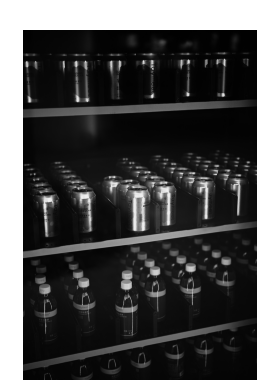


✅ Imagen cargada: 4032×6048px


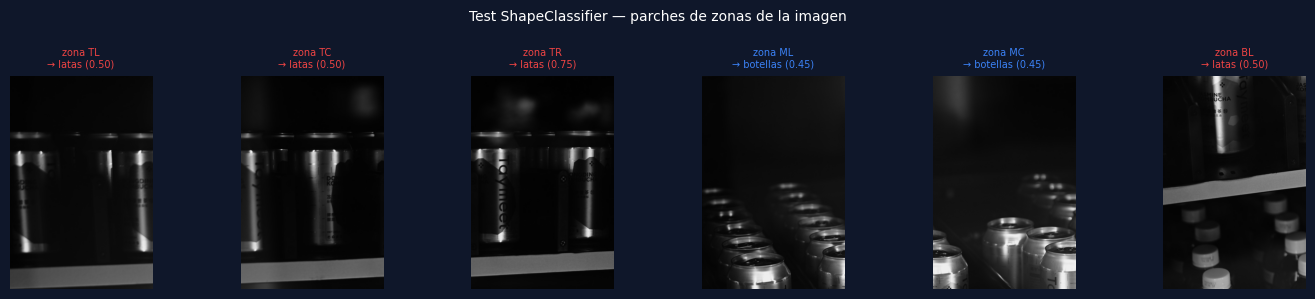

In [12]:
# Verifica que el clasificador de forma funciona en la imagen
# antes de correr el pipeline completo.
img_test = cv2.imread(IMAGE_PATH)
if img_test is None:
    print('❌ Imagen no encontrada. Verifica IMAGE_PATH en paso 2.')
else:
    plt.figure(figsize=(12,4))
    plt.imshow(cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB))
    plt.title(f'{IMAGE_NAME}  —  {img_test.shape[1]}×{img_test.shape[0]}px',
              color='white', fontsize=11)
    plt.axis('off')
    plt.tight_layout(); plt.show()
    print(f'\n✅ Imagen cargada: {img_test.shape[1]}×{img_test.shape[0]}px')
    test_shape_classifier(IMAGE_PATH)

---
## ▶ PASO 13 — Se ejecuta pipeline

In [13]:

counter = ShelfCounterV5(
    yolo_size   = 's',
    yolo_conf   = 0.10,
    grid_min_pw = 0.018,
    grid_vf     = 0.50,
    iou_thr     = 0.35,
    max_shelves = 8,
)

print('\n'+'='*68)
print(f'  PROCESANDO: {IMAGE_PATH}')
print('='*68+'\n')
results = counter.process_image(IMAGE_PATH)

🚀 Inicializando ShelfCounterV5...
  🔄 Cargando YOLOv8s...
  ✅ YOLOv8s listo.
✅ ShelfCounterV5 listo.


  PROCESANDO: /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/Data/new_image.jpg

📷 4032×6048px  |  B&N

[1/5] Perspectiva global...
   🟢 Alta confianza  —  Punto de fuga detectado. Score=1.00

[2/5] Detectando niveles de anaquel...
   Método detección niveles: Hough
   → 2 nivel(es) detectado(s)

[3/5] YOLO global...
   34 detecciones YOLO

[4/5] Grid + Contornos + Fusión + Profundidad por nivel...
   Shelf 1 (h=1354px): YOLO=4 Grid=18 Cont=4 → Fusión=20 | ×2.06
   Shelf 2 (h=4694px): YOLO=30 Grid=11 Cont=20 → Fusión=37 | ×2.21

[5/5] ✅ Análisis completado.


---
## ▶ PASO 14 — Reporte

In [14]:
report = counter.generate_report(results)
print(report)
with open(OUTPUT_REPORT,'w',encoding='utf-8') as f: f.write(report)
print(f'\n💾 {OUTPUT_REPORT}')

  CONTEO DE PRODUCTOS EN ANAQUEL  (v5 — 100% automático)
  Imagen     : new_image.jpg
  Modo       : Blanco y negro (clasificación por forma)
Perspectiva : 🟢 Alta confianza
Nota        : Punto de fuga detectado. Score=1.00
--------------------------------------------------------------------
Nivel   Tipo dominante   Visibles Est. total  Breakdown
--------------------------------------------------------------------
Shelf 1   botellas               20         41  16 botellas + 4 latas
Shelf 2   latas                  37         82  24 latas + 13 botellas
                               57        123  ← TOTAL

DETALLE DE ESTIMACIÓN DE PROFUNDIDAD
--------------------------------------------------------------------
Shelf 1: 20 vis × 2.06 = 41 est  |  conf=high | oclusión=0.03 | var_tamaño=0.80 | densidad=1.00 | ×2.06
Shelf 2: 37 vis × 2.21 = 82 est  |  conf=high | oclusión=0.19 | var_tamaño=1.00 | densidad=1.00 | ×2.21

💾 /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/Data/re

---
## ▶ PASO 15 — Visualización

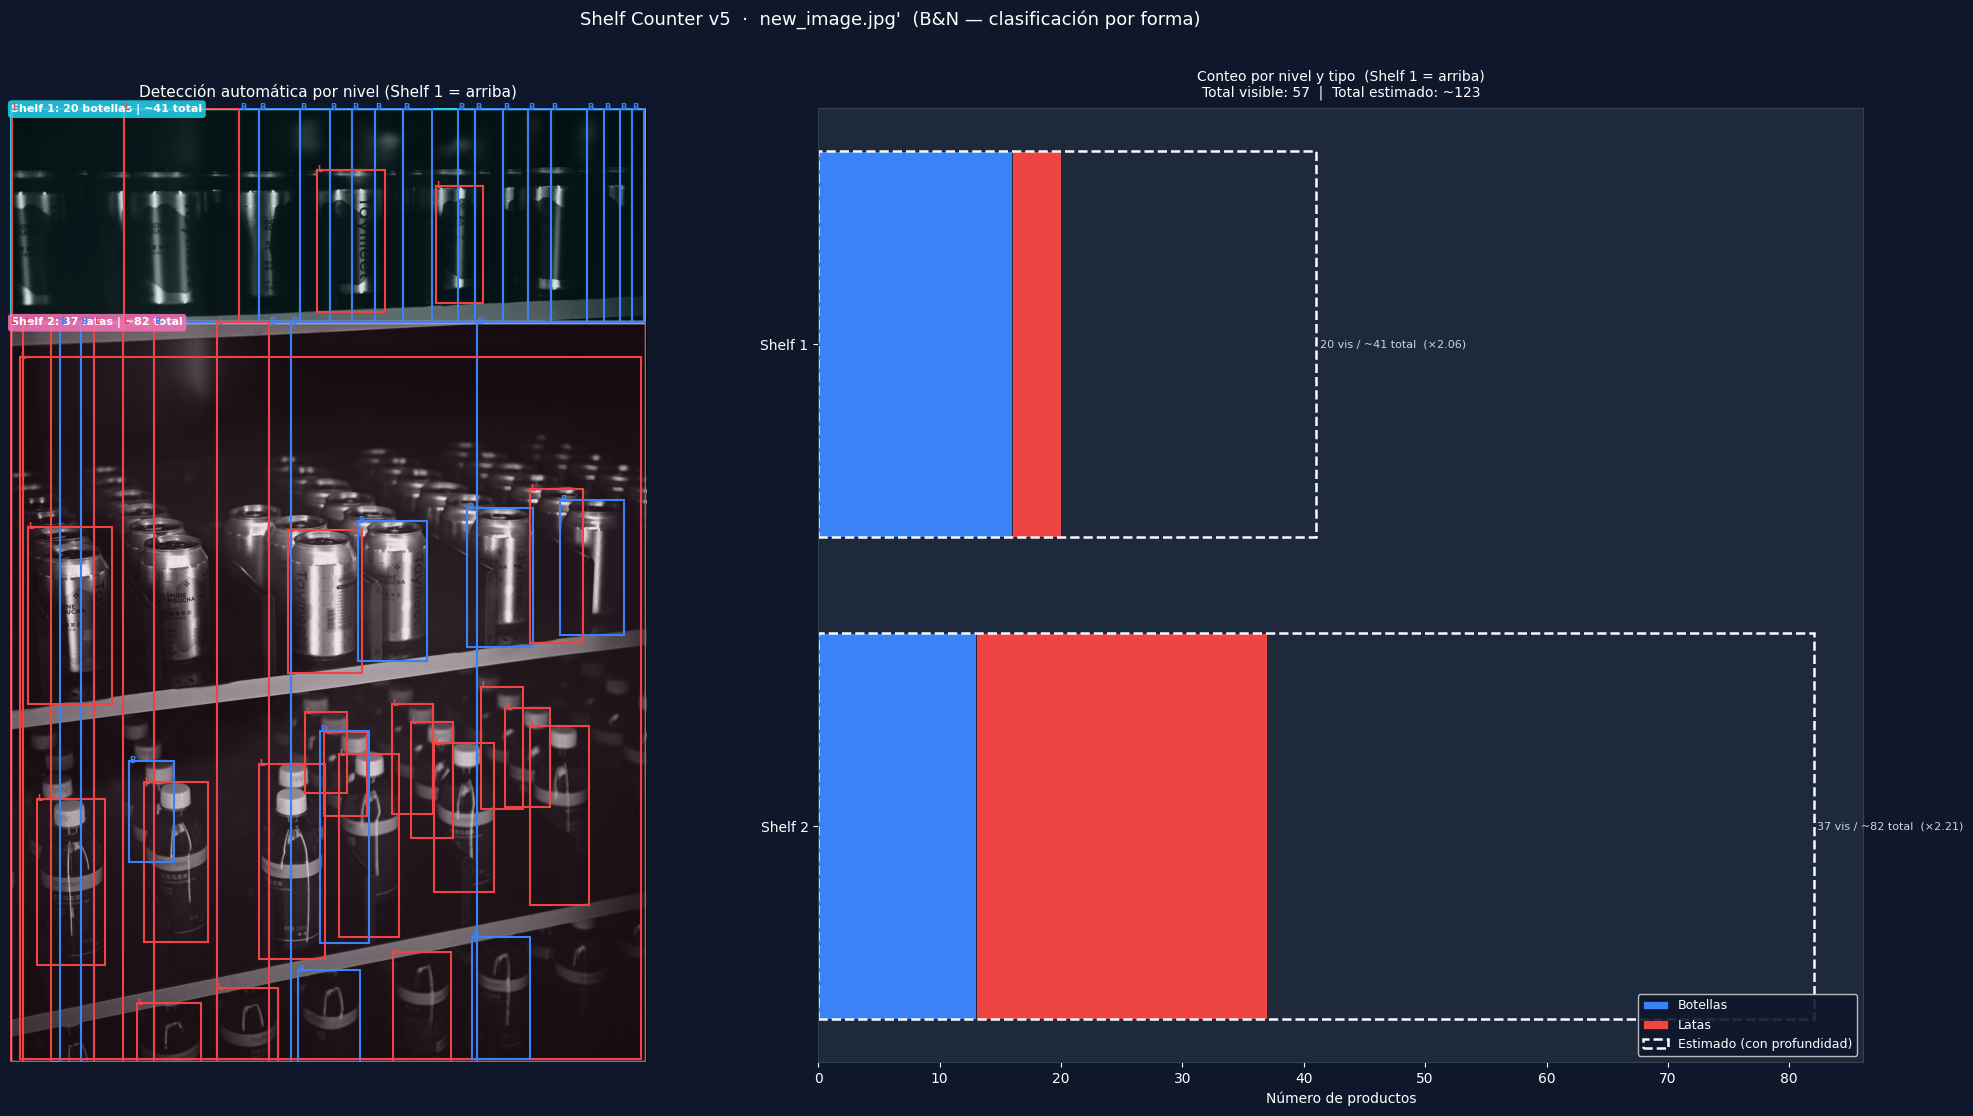

💾 /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/Data/resultados/new_image_v5_result.png


In [15]:
fig = counter.visualize(results, figsize=(22,11))
fig.savefig(OUTPUT_IMG, dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print(f'💾 {OUTPUT_IMG}')